## Task 4. Neural Networks


### 4.1. Additional processing required for neural network modelling

Neural network models require all input variables to be numeric and are sensitive to the scale of the input features. Therefore, the categorical variables are converted using one-hot encoding, and the continuous numeric variables are standardised with `StandardScaler`. Binary dummy variables are kept as 0/1 values because they already have a consistent scale. The scaler is fitted on the training data only and then applied to the test data to avoid data leakage.

The target variable is `isAboveAvg`, a binary categorical variable created from `yield_per_hec`, where 1 indicates that paddy yield per hectare is above the dataset mean and 0 otherwise.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc


In [ ]:
# Reuse the same preprocessing steps from Task 1
df = pd.read_csv('../Asm1_dataset26.csv')
df.columns = df.columns.str.strip()
df = df.drop_duplicates(keep='first')

# Impute missing values in minimum temperature columns with their median
min_temp_cols = ['Min temp_D1_D30', 'Min temp_D31_D60', 'Min temp_D61_D90', 'Min temp_D91_D120']
for col in min_temp_cols:
    df[col] = df[col].fillna(df[col].median())

# Replace '--' in categorical columns with a separate missing/unknown category
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace('--', 'NA')

# Create the binary target variable
df['yield_per_hec'] = df['Paddy yield(in Kg)'] / df['Hectares']
mean_yield = df['yield_per_hec'].mean()
df['isAboveAvg'] = np.where(df['yield_per_hec'] > mean_yield, 1, 0)

# Remove variables that directly define the target or are treated as noisy
drop_cols = ['Hectares', 'Paddy yield(in Kg)', 'yield_per_hec', 'Trash(in bundles)']
df_clean = df.drop(columns=drop_cols)

# Convert categorical variables to numeric dummy variables
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['isAboveAvg'])
y = df_encoded['isAboveAvg']

# Remove highly correlated variables using the Task 1 threshold
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.98)]
X_final = X.drop(columns=high_corr_cols)

print(f'Final feature matrix shape before neural network scaling: {X_final.shape}')
print(f'Target distribution:\n{y.value_counts()}')


Final feature matrix shape before neural network scaling: (2628, 50)
Target distribution:
isAboveAvg
0    1327
1    1301
Name: count, dtype: int64


In [18]:
# Train/test split for neural network modelling
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Scale continuous variables only; keep binary dummy variables as 0/1
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2]
continuous_cols = [col for col in X_train.columns if col not in binary_cols]

scaler = StandardScaler()
X_train_nn = X_train.copy()
X_test_nn = X_test.copy()

X_train_nn[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_nn[continuous_cols] = scaler.transform(X_test[continuous_cols])

# Convert all columns to float for MLPClassifier
X_train_nn = X_train_nn.astype(float)
X_test_nn = X_test_nn.astype(float)

print(f'Train size: {X_train_nn.shape}')
print(f'Test size: {X_test_nn.shape}')
print(f'Number of continuous variables scaled: {len(continuous_cols)}')
print(f'Number of binary variables kept as 0/1: {len(binary_cols)}')


Train size: (1971, 50)
Test size: (657, 50)
Number of continuous variables scaled: 19
Number of binary variables kept as 0/1: 31


### 4.2. Neural network model tuned with GridSearchCV

The first neural network model uses all 50 input variables after preprocessing and correlation-based feature removal. `MLPClassifier` is used for binary classification. The grid search tests small and medium hidden-layer structures, two activation functions, different L2 regularisation strengths, and two initial learning rates. These settings provide a practical search range without making the training time too large for this dataset.


In [19]:
nn = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

param_grid_nn = {
    'hidden_layer_sizes': [(25,), (50,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_nn = GridSearchCV(
    estimator=nn,
    param_grid=param_grid_nn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn.fit(X_train_nn, y_train)

best_nn = grid_search_nn.best_estimator_
y_train_pred_nn = best_nn.predict(X_train_nn)
y_test_pred_nn = best_nn.predict(X_test_nn)

train_acc_nn = accuracy_score(y_train, y_train_pred_nn)
test_acc_nn = accuracy_score(y_test, y_test_pred_nn)
accuracy_gap_nn = train_acc_nn - test_acc_nn
converged_nn = best_nn.n_iter_ < best_nn.max_iter

print('Best neural network parameters:')
print(grid_search_nn.best_params_)
print(f'Best cross-validation accuracy: {grid_search_nn.best_score_:.4f}')
print(f'Train accuracy: {train_acc_nn:.4f}')
print(f'Test accuracy: {test_acc_nn:.4f}')
print(f'Train-test accuracy gap: {accuracy_gap_nn:.4f}')
print(f'Iterations used by best model: {best_nn.n_iter_}')
print(f'Did the training stop before max_iter? {converged_nn}')
print(f'Final loss: {best_nn.loss_:.4f}')


Best neural network parameters:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.8919
Train accuracy: 0.9102
Test accuracy: 0.8904
Train-test accuracy gap: 0.0198
Iterations used by best model: 43
Did the training stop before max_iter? True
Final loss: 0.1935


In [ ]:
nn_cv_results = pd.DataFrame(grid_search_nn.cv_results_).sort_values('rank_test_score')
nn_cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_hidden_layer_sizes',
    'param_activation',
    'param_alpha',
    'param_learning_rate_init'
]].head(10)


,rank_test_score,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_alpha,param_learning_rate_init
5,1,0.891923,0.022432,"(50, 25)",relu,0.0001,0.01
27,2,0.889897,0.015738,"(50,)",tanh,0.0010,0.01
21,2,0.889897,0.015738,"(50,)",tanh,0.0001,0.01
33,4,0.888881,0.015643,"(50,)",tanh,0.0100,0.01
35,5,0.888372,0.014943,"(50, 25)",tanh,0.0100,0.01
29,5,0.888372,0.014943,"(50, 25)",tanh,0.0010,0.01
23,5,0.888372,0.014943,"(50, 25)",tanh,0.0001,0.01
17,8,0.887866,0.016132,"(50, 25)",relu,0.0100,0.01
13,9,0.887865,0.015319,"(25,)",relu,0.0100,0.01
1,10,0.887862,0.017453,"(25,)",relu,0.0001,0.01


#### Summary for the full neural network model

- The model uses `MLPClassifier` with the `adam` solver and all 50 input variables from `X_final`.
- The train/test split is 75% training and 25% testing, with `random_state=42` and `stratify=y` to preserve the class distribution.
- The hyperparameter search includes hidden-layer structures `(25,)`, `(50,)`, and `(50, 25)`, activation functions `relu` and `tanh`, L2 regularisation strengths `0.0001`, `0.001`, and `0.01`, and initial learning rates `0.001` and `0.01`.
- The best model found during verification used `activation='relu'`, `alpha=0.0001`, `hidden_layer_sizes=(50, 25)`, and `learning_rate_init=0.01`.
- The best cross-validation accuracy was 0.8919. The training accuracy was 0.9102 and the test accuracy was 0.8904.
- The train-test accuracy gap was 0.0198, so the model does not show strong evidence of overfitting.
- The best model stopped after 43 iterations, before reaching `max_iter=1000`. With `early_stopping=True`, this indicates that training stopped once validation performance stopped improving, and the best validation model was retained.


### 4.3. Neural network model with reduced feature set

The reduced feature set is selected using the best decision tree settings from Task 2. Features with non-zero importance in the tuned decision tree are retained. This method is interpretable and consistent with the assignment requirement to use a subset of inputs found significant by the best decision tree model.


In [21]:
# Feature selection using the best decision tree settings from Task 2
feature_selector_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=20,
    random_state=42
)

feature_selector_tree.fit(X_train, y_train)

tree_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_selector_tree.feature_importances_
}).sort_values(by='Importance', ascending=False)

important_features_nn = tree_importance.loc[tree_importance['Importance'] > 0, 'Feature'].tolist()

print(f'Number of selected features: {len(important_features_nn)}')
for idx, feature in enumerate(important_features_nn, start=1):
    print(idx, feature)

tree_importance.head(15)


Number of selected features: 13
1 Seedrate(in Kg)
2 Variety_delux ponni
3 Variety_ponmani
4 Relative Humidity_D31_D60
5 Max temp_D61_D90
6 Wind Direction_D61_D90_NNW
7 Wind Direction_D31_D60_NE
8 51_70DRain(in mm)
9 Wind Direction_D1_D30_NA
10 Wind Direction_D61_D90_SW
11 Nursery_wet
12 Soil Types_clay
13 Wind Direction_D31_D60_W


,Feature,Importance
0,Seedrate(in Kg),0.946465
24,Variety_delux ponni,0.030967
25,Variety_ponmani,0.007056
16,Relative Humidity_D31_D60,0.004621
8,Max temp_D61_D90,0.004553
41,Wind Direction_D61_D90_NNW,0.001934
35,Wind Direction_D31_D60_NE,0.001361
3,51_70DRain(in mm),0.000987
29,Wind Direction_D1_D30_NA,0.000847
43,Wind Direction_D61_D90_SW,0.000466


In [22]:
X_train_reduced_nn = X_train_nn[important_features_nn]
X_test_reduced_nn = X_test_nn[important_features_nn]

nn_reduced = MLPClassifier(
    solver='adam',
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

param_grid_nn_reduced = {
    'hidden_layer_sizes': [(10,), (25,), (25, 10)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_nn_reduced = GridSearchCV(
    estimator=nn_reduced,
    param_grid=param_grid_nn_reduced,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_nn_reduced.fit(X_train_reduced_nn, y_train)

best_nn_reduced = grid_search_nn_reduced.best_estimator_
y_train_pred_nn_reduced = best_nn_reduced.predict(X_train_reduced_nn)
y_test_pred_nn_reduced = best_nn_reduced.predict(X_test_reduced_nn)

train_acc_nn_reduced = accuracy_score(y_train, y_train_pred_nn_reduced)
test_acc_nn_reduced = accuracy_score(y_test, y_test_pred_nn_reduced)
accuracy_gap_nn_reduced = train_acc_nn_reduced - test_acc_nn_reduced
converged_nn_reduced = best_nn_reduced.n_iter_ < best_nn_reduced.max_iter

print('Best reduced neural network parameters:')
print(grid_search_nn_reduced.best_params_)
print(f'Best cross-validation accuracy: {grid_search_nn_reduced.best_score_:.4f}')
print(f'Train accuracy: {train_acc_nn_reduced:.4f}')
print(f'Test accuracy: {test_acc_nn_reduced:.4f}')
print(f'Train-test accuracy gap: {accuracy_gap_nn_reduced:.4f}')
print(f'Iterations used by best model: {best_nn_reduced.n_iter_}')
print(f'Did the training stop before max_iter? {converged_nn_reduced}')
print(f'Final loss: {best_nn_reduced.loss_:.4f}')


Best reduced neural network parameters:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (25, 10), 'learning_rate_init': 0.01}
Best cross-validation accuracy: 0.8914
Train accuracy: 0.9026
Test accuracy: 0.8935
Train-test accuracy gap: 0.0091
Iterations used by best model: 39
Did the training stop before max_iter? True
Final loss: 0.2194


In [23]:
nn_reduced_cv_results = pd.DataFrame(grid_search_nn_reduced.cv_results_).sort_values('rank_test_score')
nn_reduced_cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_hidden_layer_sizes',
    'param_activation',
    'param_alpha',
    'param_learning_rate_init'
]].head(10)


,rank_test_score,mean_test_score,std_test_score,param_hidden_layer_sizes,param_activation,param_alpha,param_learning_rate_init
17,1,0.891417,0.021054,"(25, 10)",relu,0.0100,0.01
11,1,0.891417,0.019986,"(25, 10)",relu,0.0010,0.01
5,3,0.891416,0.017444,"(25, 10)",relu,0.0001,0.01
9,4,0.889894,0.016313,"(25,)",relu,0.0010,0.01
15,4,0.889894,0.016313,"(25,)",relu,0.0100,0.01
3,6,0.889386,0.017161,"(25,)",relu,0.0001,0.01
21,7,0.888879,0.020998,"(25,)",tanh,0.0001,0.01
27,7,0.888879,0.020998,"(25,)",tanh,0.0010,0.01
33,7,0.888879,0.020998,"(25,)",tanh,0.0100,0.01
13,10,0.887871,0.013775,"(10,)",relu,0.0100,0.01


#### Summary for the reduced neural network model

- The reduced model uses features selected by the tuned decision tree from Task 2, keeping only variables with non-zero feature importance.
- During verification, 13 variables were selected: `Seedrate(in Kg)`, `Variety_delux ponni`, `Variety_ponmani`, `Relative Humidity_D31_D60`, `Max temp_D61_D90`, `Wind Direction_D61_D90_NNW`, `Wind Direction_D31_D60_NE`, `51_70DRain(in mm)`, `Wind Direction_D1_D30_NA`, `Wind Direction_D61_D90_SW`, `Nursery_wet`, `Soil Types_clay`, and `Wind Direction_D31_D60_W`.
- The same train/test split is used as the full neural network model, but the input matrix is reduced from 50 variables to 13 variables.
- A smaller neural network architecture search is used because the reduced model has fewer input variables: `(10,)`, `(25,)`, and `(25, 10)`.
- The best reduced model found during verification used `activation='relu'`, `alpha=0.001`, `hidden_layer_sizes=(25, 10)`, and `learning_rate_init=0.01`.
- The best cross-validation accuracy was 0.8914. The training accuracy was 0.9026 and the test accuracy was 0.8935.
- The train-test accuracy gap was 0.0091, so the reduced model does not show strong evidence of overfitting.
- The best reduced model stopped after 39 iterations, before reaching `max_iter=1000`. With `early_stopping=True`, this indicates that training stopped once validation performance stopped improving.
- Compared with the full neural network model, the reduced model achieved slightly higher test accuracy with far fewer input variables, so feature selection was helpful in reducing complexity while preserving predictive performance.


### 4.4. ROC curve comparison for neural network models

The ROC curve compares the full neural network and the reduced neural network on the same test set. A higher AUC indicates stronger ability to separate fields with above-average yield from fields with below-average yield across different classification thresholds.


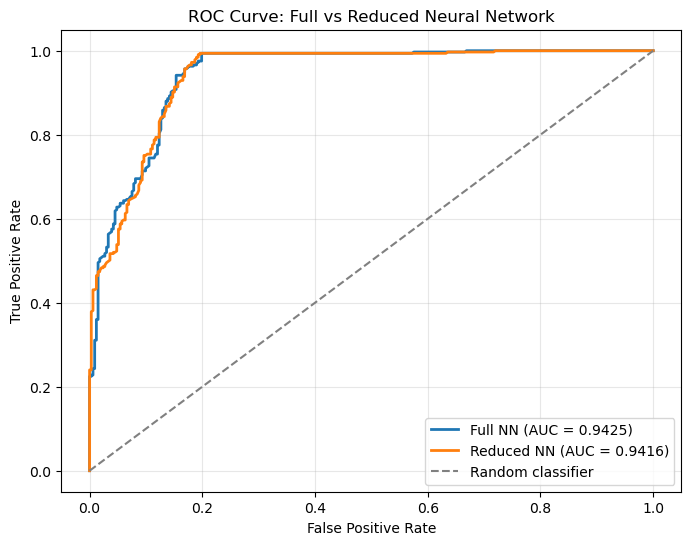

Full neural network AUC: 0.9425
Reduced neural network AUC: 0.9416


In [24]:
y_prob_nn = best_nn.predict_proba(X_test_nn)[:, 1]
y_prob_nn_reduced = best_nn_reduced.predict_proba(X_test_reduced_nn)[:, 1]

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
fpr_nn_reduced, tpr_nn_reduced, _ = roc_curve(y_test, y_prob_nn_reduced)

auc_nn = auc(fpr_nn, tpr_nn)
auc_nn_reduced = auc(fpr_nn_reduced, tpr_nn_reduced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nn, tpr_nn, label=f'Full NN (AUC = {auc_nn:.4f})', linewidth=2)
plt.plot(fpr_nn_reduced, tpr_nn_reduced, label=f'Reduced NN (AUC = {auc_nn_reduced:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Full vs Reduced Neural Network')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'Full neural network AUC: {auc_nn:.4f}')
print(f'Reduced neural network AUC: {auc_nn_reduced:.4f}')


#### ROC comparison summary

- The full neural network uses all 50 input variables, while the reduced neural network uses the 13 variables selected by the tuned decision tree.
- During verification, the full neural network had an AUC of 0.9425, while the reduced neural network had an AUC of 0.9416. The AUC values are almost identical, with the full model only slightly higher.
- The reduced neural network had slightly higher test accuracy than the full neural network, 0.8935 compared with 0.8904, while using far fewer input variables.
- Because the reduced model has almost the same AUC and slightly higher test accuracy with only 13 variables, the feature selection outcome is useful for reducing complexity while preserving predictive performance.
- Both neural network models are less directly interpretable than decision trees or logistic regression because the learned relationships are distributed across hidden-layer weights.
- Neural networks are sensitive to hyperparameters such as hidden-layer size, activation function, regularisation strength, and learning rate, so GridSearchCV is used to select a more reliable configuration.
- The train-test accuracy gaps for both neural networks are small, so neither model shows strong evidence of overfitting in this run.
